In [7]:
import pandas as pd

df = pd.read_csv("AccidentsBig.csv", low_memory=False)
df 

,Accident_Index,longitude,latitude,Police_Force,Accident_Severity,Number_of_Vehicles,Number_of_Casualties,Day_of_Week,Time,Local_Authority_(District),...,Pedestrian_Crossing-Physical_Facilities,Light_Conditions,Weather_Conditions,Road_Surface_Conditions,Special_Conditions_at_Site,Carriageway_Hazards,Urban_or_Rural_Area,Did_Police_Officer_Attend_Scene_of_Accident,LSOA_of_Accident_Location,Date
0,1.0,78.610393,14.724026,1.0,2.0,1.0,1.0,3.0,17:42,12.0,...,1.0,1.0,2.0,2.0,0.0,0.0,1.0,1.0,E01002849,04-01-2018
1,2.0,78.534042,14.762353,1.0,3.0,1.0,1.0,4.0,17:36,12.0,...,5.0,4.0,1.0,1.0,0.0,0.0,1.0,1.0,E01002909,05-01-2018
2,3.0,78.470877,14.745606,1.0,3.0,2.0,1.0,5.0,00:15,12.0,...,0.0,4.0,1.0,1.0,0.0,0.0,1.0,1.0,E01002857,06-01-2018
3,4.0,78.557994,14.667128,1.0,3.0,1.0,1.0,6.0,10:35,12.0,...,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,E01002840,07-01-2018
4,5.0,78.576431,14.703443,1.0,3.0,1.0,1.0,2.0,21:13,12.0,...,0.0,7.0,1.0,2.0,0.0,0.0,1.0,1.0,E01002863,10-01-2018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048570,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1048571,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1048572,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1048573,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
df = df[['Number_of_Vehicles', 'Accident_Severity']]
df

,Number_of_Vehicles,Accident_Severity
0,1.0,2.0
1,1.0,3.0
2,2.0,3.0
3,1.0,3.0
4,1.0,3.0
...,...,...
1048570,NaN,NaN
1048571,NaN,NaN
1048572,NaN,NaN
1048573,NaN,NaN


In [14]:
# For filling missing values in 'Number_of_Vehicles' with its mean
df['Number_of_Vehicles'] = df['Number_of_Vehicles'].fillna(df['Number_of_Vehicles'].mean())
df
# For filling missing values in 'Accident_Severity' with its mean
df['Accident_Severity'] = df['Accident_Severity'].fillna(df['Accident_Severity'].mean())
df

,Number_of_Vehicles,Accident_Severity
0,1.000000,2.000000
1,1.000000,3.000000
2,2.000000,3.000000
3,1.000000,3.000000
4,1.000000,3.000000
...,...,...
1048570,1.832028,2.855512
1048571,1.832028,2.855512
1048572,1.832028,2.855512
1048573,1.832028,2.855512


In [16]:
duplicates = df.duplicated().sum()
if duplicates > 0:
    df.drop_duplicates(inplace=True)
df

,Number_of_Vehicles,Accident_Severity
0,1.000000,2.000000
1,1.000000,3.000000
2,2.000000,3.000000
16,2.000000,2.000000
34,4.000000,3.000000
60,3.000000,3.000000
208,3.000000,2.000000
578,4.000000,2.000000
730,5.000000,3.000000
824,2.000000,1.000000


In [18]:
Q1 = df['Number_of_Vehicles'].quantile(0.25)
Q3 = df['Number_of_Vehicles'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df

,Number_of_Vehicles,Accident_Severity
0,1.000000,2.000000
1,1.000000,3.000000
2,2.000000,3.000000
16,2.000000,2.000000
34,4.000000,3.000000
60,3.000000,3.000000
208,3.000000,2.000000
578,4.000000,2.000000
730,5.000000,3.000000
824,2.000000,1.000000


In [28]:
df = df[(df['Number_of_Vehicles'] >= lower_bound) & (df['Number_of_Vehicles'] <= upper_bound)]
df

,Number_of_Vehicles,Accident_Severity
0,-1.335985,2.000000
1,-1.335985,3.000000
2,-1.018520,3.000000
16,-1.018520,2.000000
34,-0.383589,3.000000
60,-0.701054,3.000000
208,-0.701054,2.000000
578,-0.383589,2.000000
730,-0.066124,3.000000
824,-1.018520,1.000000


In [29]:
X = df[['Number_of_Vehicles']]
y = df['Accident_Severity']


In [32]:
from sklearn.model_selection import train_test_split

# Assuming X and y are defined (features and target variables)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [34]:
from sklearn.linear_model import LinearRegression

# Assuming X_train and y_train are defined
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [36]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R^2 Score:", r2)


Mean Squared Error: 0.7386904121731414
Root Mean Squared Error: 0.8594710071742626
R^2 Score: 0.08300500557816937


In [37]:
print("📊 Model Evaluation:")
print(f"Mean Squared Error (MSE): {mse:.3f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")
print(f"R-squared (R²): {r2:.3f}")


📊 Model Evaluation:
Mean Squared Error (MSE): 0.739
Root Mean Squared Error (RMSE): 0.859
R-squared (R²): 0.083


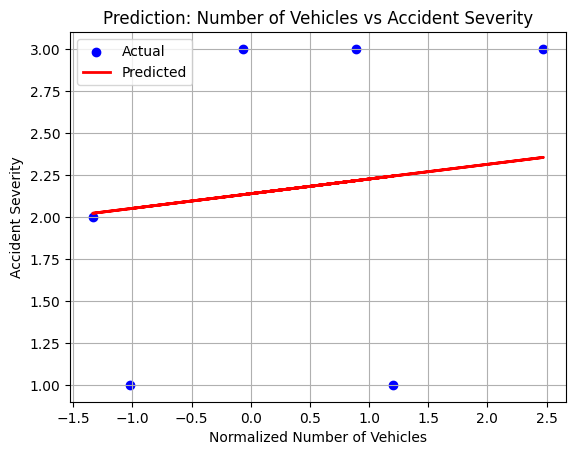

In [41]:
import matplotlib.pyplot as plt

plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Predicted')
plt.xlabel('Normalized Number of Vehicles')
plt.ylabel('Accident Severity')
plt.title('Prediction: Number of Vehicles vs Accident Severity')
plt.legend()
plt.grid(True)
plt.show()


C:\Users\Gowsika\AppData\Local\Temp\ipykernel_13900\50495671.py:6: DtypeWarning: Columns (8,10,28,29) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('AccidentsBig.csv')


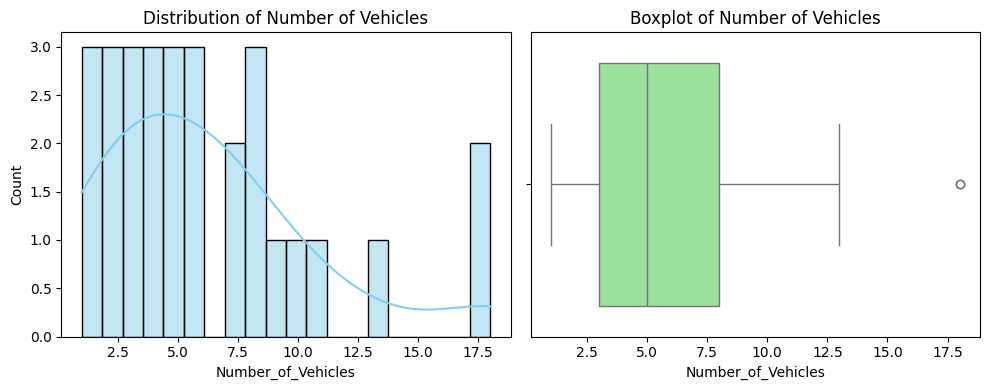

C:\Users\Gowsika\AppData\Local\Temp\ipykernel_13900\50495671.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Accident_Severity', data=df, palette='Set2')


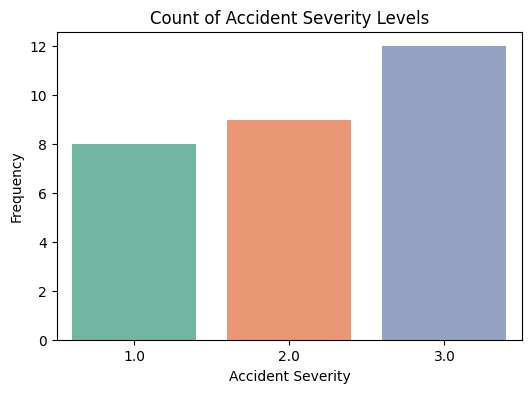

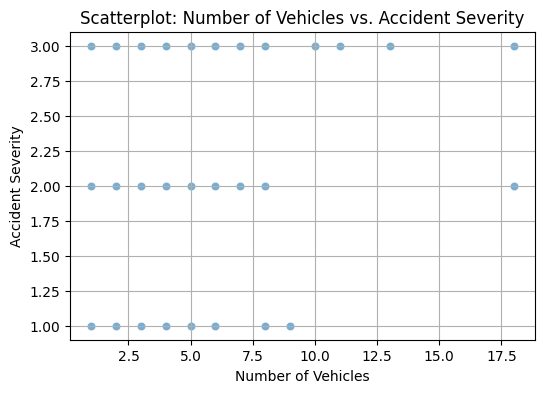

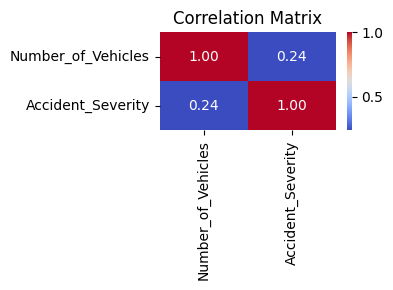

In [43]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('AccidentsBig.csv')

# Select relevant columns and drop missing values
df = df[['Number_of_Vehicles', 'Accident_Severity']].dropna()

# Remove duplicates
df.drop_duplicates(inplace=True)

# Univariate Analysis - Histogram and Boxplot
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['Number_of_Vehicles'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Number of Vehicles')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['Number_of_Vehicles'], color='lightgreen')
plt.title('Boxplot of Number of Vehicles')
plt.tight_layout()
plt.show()

# Countplot for Accident Severity
plt.figure(figsize=(6, 4))
sns.countplot(x='Accident_Severity', data=df, palette='Set2')
plt.title('Count of Accident Severity Levels')
plt.xlabel('Accident Severity')
plt.ylabel('Frequency')
plt.show()

# Bivariate Analysis - Scatterplot
plt.figure(figsize=(6, 4))
sns.scatterplot(x='Number_of_Vehicles', y='Accident_Severity', data=df, alpha=0.6)
plt.title('Scatterplot: Number of Vehicles vs. Accident Severity')
plt.xlabel('Number of Vehicles')
plt.ylabel('Accident Severity')
plt.grid(True)
plt.show()

# Correlation Matrix
plt.figure(figsize=(4, 3))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [6]:

import pandas as pd

df = pd.read_csv("AccidentsBig.csv", low_memory=False)
print(df.shape)  # Outputs (rows, columns)



(1048575, 30)


In [4]:
print(df.head)

<bound method NDFrame.head of          Accident_Index  longitude   latitude  Police_Force  \
0                   1.0  78.610393  14.724026           1.0   
1                   2.0  78.534042  14.762353           1.0   
2                   3.0  78.470877  14.745606           1.0   
3                   4.0  78.557994  14.667128           1.0   
4                   5.0  78.576431  14.703443           1.0   
...                 ...        ...        ...           ...   
1048570             NaN        NaN        NaN           NaN   
1048571             NaN        NaN        NaN           NaN   
1048572             NaN        NaN        NaN           NaN   
1048573             NaN        NaN        NaN           NaN   
1048574             NaN        NaN        NaN           NaN   

         Accident_Severity  Number_of_Vehicles  Number_of_Casualties  \
0                      2.0                 1.0                   1.0   
1                      3.0                 1.0                   1.0 

In [8]:
import pickle
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
# Load dataset
X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
# Train model
model = LogisticRegression()
model.fit(X_train, y_train)

# Save trained model
with open("model.pkl", "wb") as file:
    pickle.dump(model, file)
